# SOGlasso Quickstart

Reference implementation of the **Sparse Overlapping Group (SOG) Lasso**
from Rao, Nowak, Cox & Rogers (2014), *"Classification with Sparse
Overlapping Groups"* (arXiv:1402.4512).

This notebook demonstrates the core estimator: fitting SOGlasso on a
synthetic (k, l)-group-sparse regression problem with overlapping groups,
and comparing recovery against plain Lasso.

The penalty being minimized (Eq. 8 in the paper):

$$h(x) = \inf_{\{w_G\} \in \mathcal{W}(x)} \sum_{G \in \mathcal{G}} \left( \|w_G\|_2 + \mu \|w_G\|_1 \right)$$

which encourages solutions supported on a *small number of groups*, each of
which is itself *sparse* -- exactly the structure motivated by the paper's
fMRI application (Figure 2).

In [1]:
import numpy as np
from soglasso import make_sog_regression, sog_lasso, lasso, overlapping_group_lasso, group_lasso

np.random.seed(0)

## 1. Generate a synthetic group-sparse problem

We build `n_groups` overlapping groups (sliding window, as in the paper's
toy experiment, Section 5.2), pick `k_active` of them to be "on", and
within each active group retain only a fraction `alpha` of coefficients.

In [2]:
Phi, y, x_star, groups = make_sog_regression(
    n_samples=150, n_groups=30, group_size=6, shift=4,
    k_active=4, alpha=0.4, noise_std=0.1, random_state=42,
)
p = Phi.shape[1]
print(f"n={Phi.shape[0]}, p={p}, num groups={len(groups)}, true nnz={np.count_nonzero(x_star)}")

n=150, p=122, num groups=30, true nnz=8


## 2. Fit SOGlasso and compare to Lasso / Overlapping Group Lasso

In [3]:
m_sog = sog_lasso(groups, mu=0.5, eta1=0.5, eta2=1e-4, max_iter=400)
m_sog.fit(Phi, y)

m_lasso = lasso(p, eta1=0.5, eta2=1e-4, max_iter=400)
m_lasso.fit(Phi, y)

m_og = overlapping_group_lasso(groups, eta1=0.5, eta2=1e-4, max_iter=400)
m_og.fit(Phi, y)

for name, m in [("SOGlasso", m_sog), ("Lasso", m_lasso), ("OGlasso", m_og)]:
    err = np.linalg.norm(m.coef_ - x_star)
    nnz = np.count_nonzero(np.abs(m.coef_) > 1e-3)
    print(f"{name:10s}  ||xhat - x*||_2 = {err:.4f}   nnz(xhat) = {nnz:4d}   (true nnz = {np.count_nonzero(x_star)})")

SOGlasso    ||xhat - x*||_2 = 0.0715   nnz(xhat) =   77   (true nnz = 8)
Lasso       ||xhat - x*||_2 = 0.0662   nnz(xhat) =   67   (true nnz = 8)
OGlasso     ||xhat - x*||_2 = 0.1029   nnz(xhat) =  109   (true nnz = 8)


## 3. Visualize the recovered support

SOGlasso should recover a sparsity pattern that is both concentrated in a
few groups *and* sparse within those groups -- unlike Lasso (scattered,
ignores group structure) or OGlasso (tends to select entire groups).

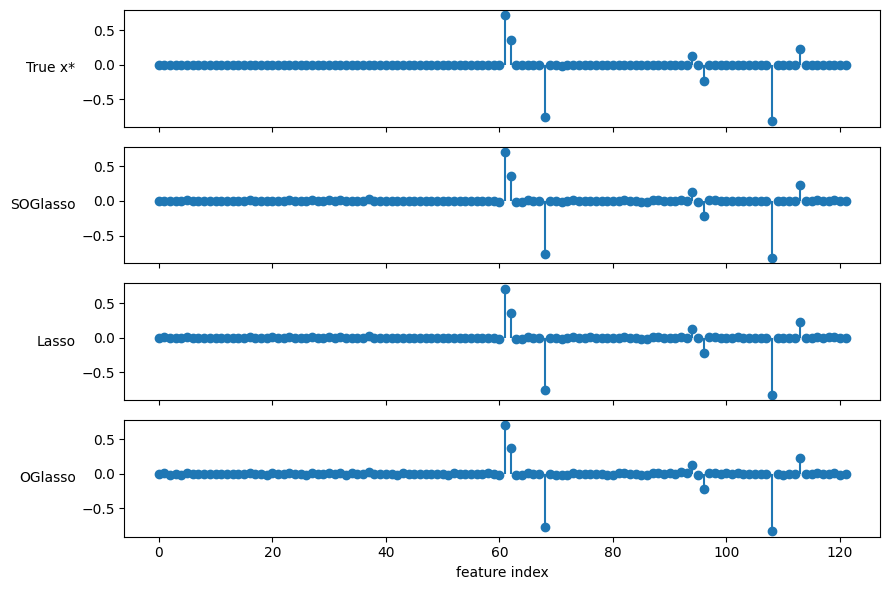

In [4]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(4, 1, figsize=(9, 6), sharex=True)
for ax, (name, coef) in zip(
    axes,
    [("True x*", x_star), ("SOGlasso", m_sog.coef_), ("Lasso", m_lasso.coef_), ("OGlasso", m_og.coef_)],
):
    ax.stem(coef, basefmt=" ")
    ax.set_ylabel(name, rotation=0, ha="right", va="center")
plt.xlabel("feature index")
plt.tight_layout()
plt.show()